In [1]:
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import scienceplots
import seaborn as sns

In [2]:
RESULTS_DF = "../data/results.parquet"

In [3]:
df = pd.read_parquet(RESULTS_DF)

In [4]:
# Use output_ebit_count if available, otherwise fallback to distribution_cost (which is reported in some timeout executions)
df["partition_ebit_cost"] = df["output_ebit_count"].fillna(df["distribution_cost"])

In [5]:
# Filter to only include benchmarks of interest
BENCHMARK_ORDER = [
    "cp",
    "qaoa",
    "qft",
    "qv",
]

def benchmark_family(name):
    s = str(name).lower()
    if "cp_scaling" in s or s == "cp":
        return "cp"
    if "qft" in s:
        return "qft"
    if "qaoa" in s:
        return "qaoa"
    if "qv" in s:
        return "qv"

    return "other"

df["benchmark_family"] = df["benchmark"].apply(benchmark_family)
df = df[df["benchmark_family"].isin(BENCHMARK_ORDER)].copy()
BENCHMARK_ORDER = [b.upper() for b in BENCHMARK_ORDER]
df["benchmark_family"] = df["benchmark_family"].str.upper()

In [6]:
# Filter to only include partitioners of interest
PARTITIONER_ORDER = [
    "fgp-roee",
    "mlfm-r",
    "pytket-dqc-esd",
]
df = df[df["partitioner"].isin(PARTITIONER_ORDER)].copy()

In [7]:
# Rename network_topology values for consistency
df["network_topology"] = df["network_topology"].replace("mesh", "grid")

In [8]:
CIRCUIT_METRICS = [
    "circuit_depth",
    ##
    "gate_density",
    "retention_lifespan",
    "entanglement_variance",
    ##
    "communication_supermarq",
    "critical_depth_supermarq",
    "entanglement_ratio_supermarq",
    "parallelism_supermarq",
    "liveness_supermarq",
    ##
    "gate_node_count",
]

# Compute ratios and deltas for each metric
for metric in CIRCUIT_METRICS:
    input_col = f"input_{metric}"
    output_col = f"output_{metric}"
    ratio_col = f"{metric}_ratio"
    delta_col = f"{metric}_delta"

    df[ratio_col] = df[output_col] / df[input_col]
    df[delta_col] = df[output_col] - df[input_col]

# Define our key targets
TARGET_METRICS = [
    *[f"{metric}_ratio" for metric in CIRCUIT_METRICS],
    *[f"{metric}_delta" for metric in CIRCUIT_METRICS],
    ##
    "partition_ebit_cost",
    ##
    "partition_exec_time_s",
]

In [9]:
# Filter to only include experiments that have all target metrics available for all partitioners

EXPERIMENT_COLS = ["circuit", "benchmark", "num_qpus", "network_topology"]
valid_groups = (
    df[df[TARGET_METRICS].notna().all(axis=1)]
    .groupby(EXPERIMENT_COLS)["partitioner"]
    .nunique()
    .reset_index(name="valid_partitioner_count")
)

ALL_PARTITIONERS = sorted(df["partitioner"].dropna().unique())
complete_groups = valid_groups[
    valid_groups["valid_partitioner_count"] == len(ALL_PARTITIONERS)
][EXPERIMENT_COLS].copy()

complete_experiments_df = df.merge(complete_groups, on=EXPERIMENT_COLS, how="inner")

In [10]:
# Map partitioner names to more readable labels for plotting
PARTITIONER_LABEL_MAP = {
    "fgp": "FGP",
    "fgp-roee": "FGP-rOEE",
    "mlfm-r": "MLFM-R",
    "pytket-dqc-p": "Pytket P",
    "pytket-dqc-pe": "Pytket PE",
    "pytket-dqc-esd": "Pytket ESD",
}
all_partitioners = sorted(complete_experiments_df["partitioner"].dropna().unique())
complete_experiments_df["partitioner"] = (
    complete_experiments_df["partitioner"]
    .map(PARTITIONER_LABEL_MAP)
    .fillna(complete_experiments_df["partitioner"])
)
PARTITIONER_LABELS = [PARTITIONER_LABEL_MAP.get(p, p) for p in all_partitioners]

In [11]:
# Plotting configuration

plt.style.use(["science", "ieee", "grid"])

matplotlib.rcParams.update(
    {
        "font.family": "serif",
        "text.usetex": True,
    }
)

PARTITIONER_PALETTE = {
    "FGP": "#E69F00",
    "FGP-rOEE": "#D55E00",
    "MLFM-R": "#009E73",
    "Pytket P": "#CC79A7",
    "Pytket PE": "#56B4E9",
    "Pytket ESD": "#8172B3",
}

TOPOLOGY_MARKER_MAP = {
    "linear": "^",
    "grid": "s",
    "fully_connected": "o",
}

COLUMN_WIDTH = 3.2
BETWEEN_COLUMN_SPACING = 0.14
ASPECT_RATIO = 1/1.25
SCALE = 1.0
FIGURE_WIDTH = COLUMN_WIDTH * SCALE
FIGURE_HEIGHT = FIGURE_WIDTH * ASPECT_RATIO

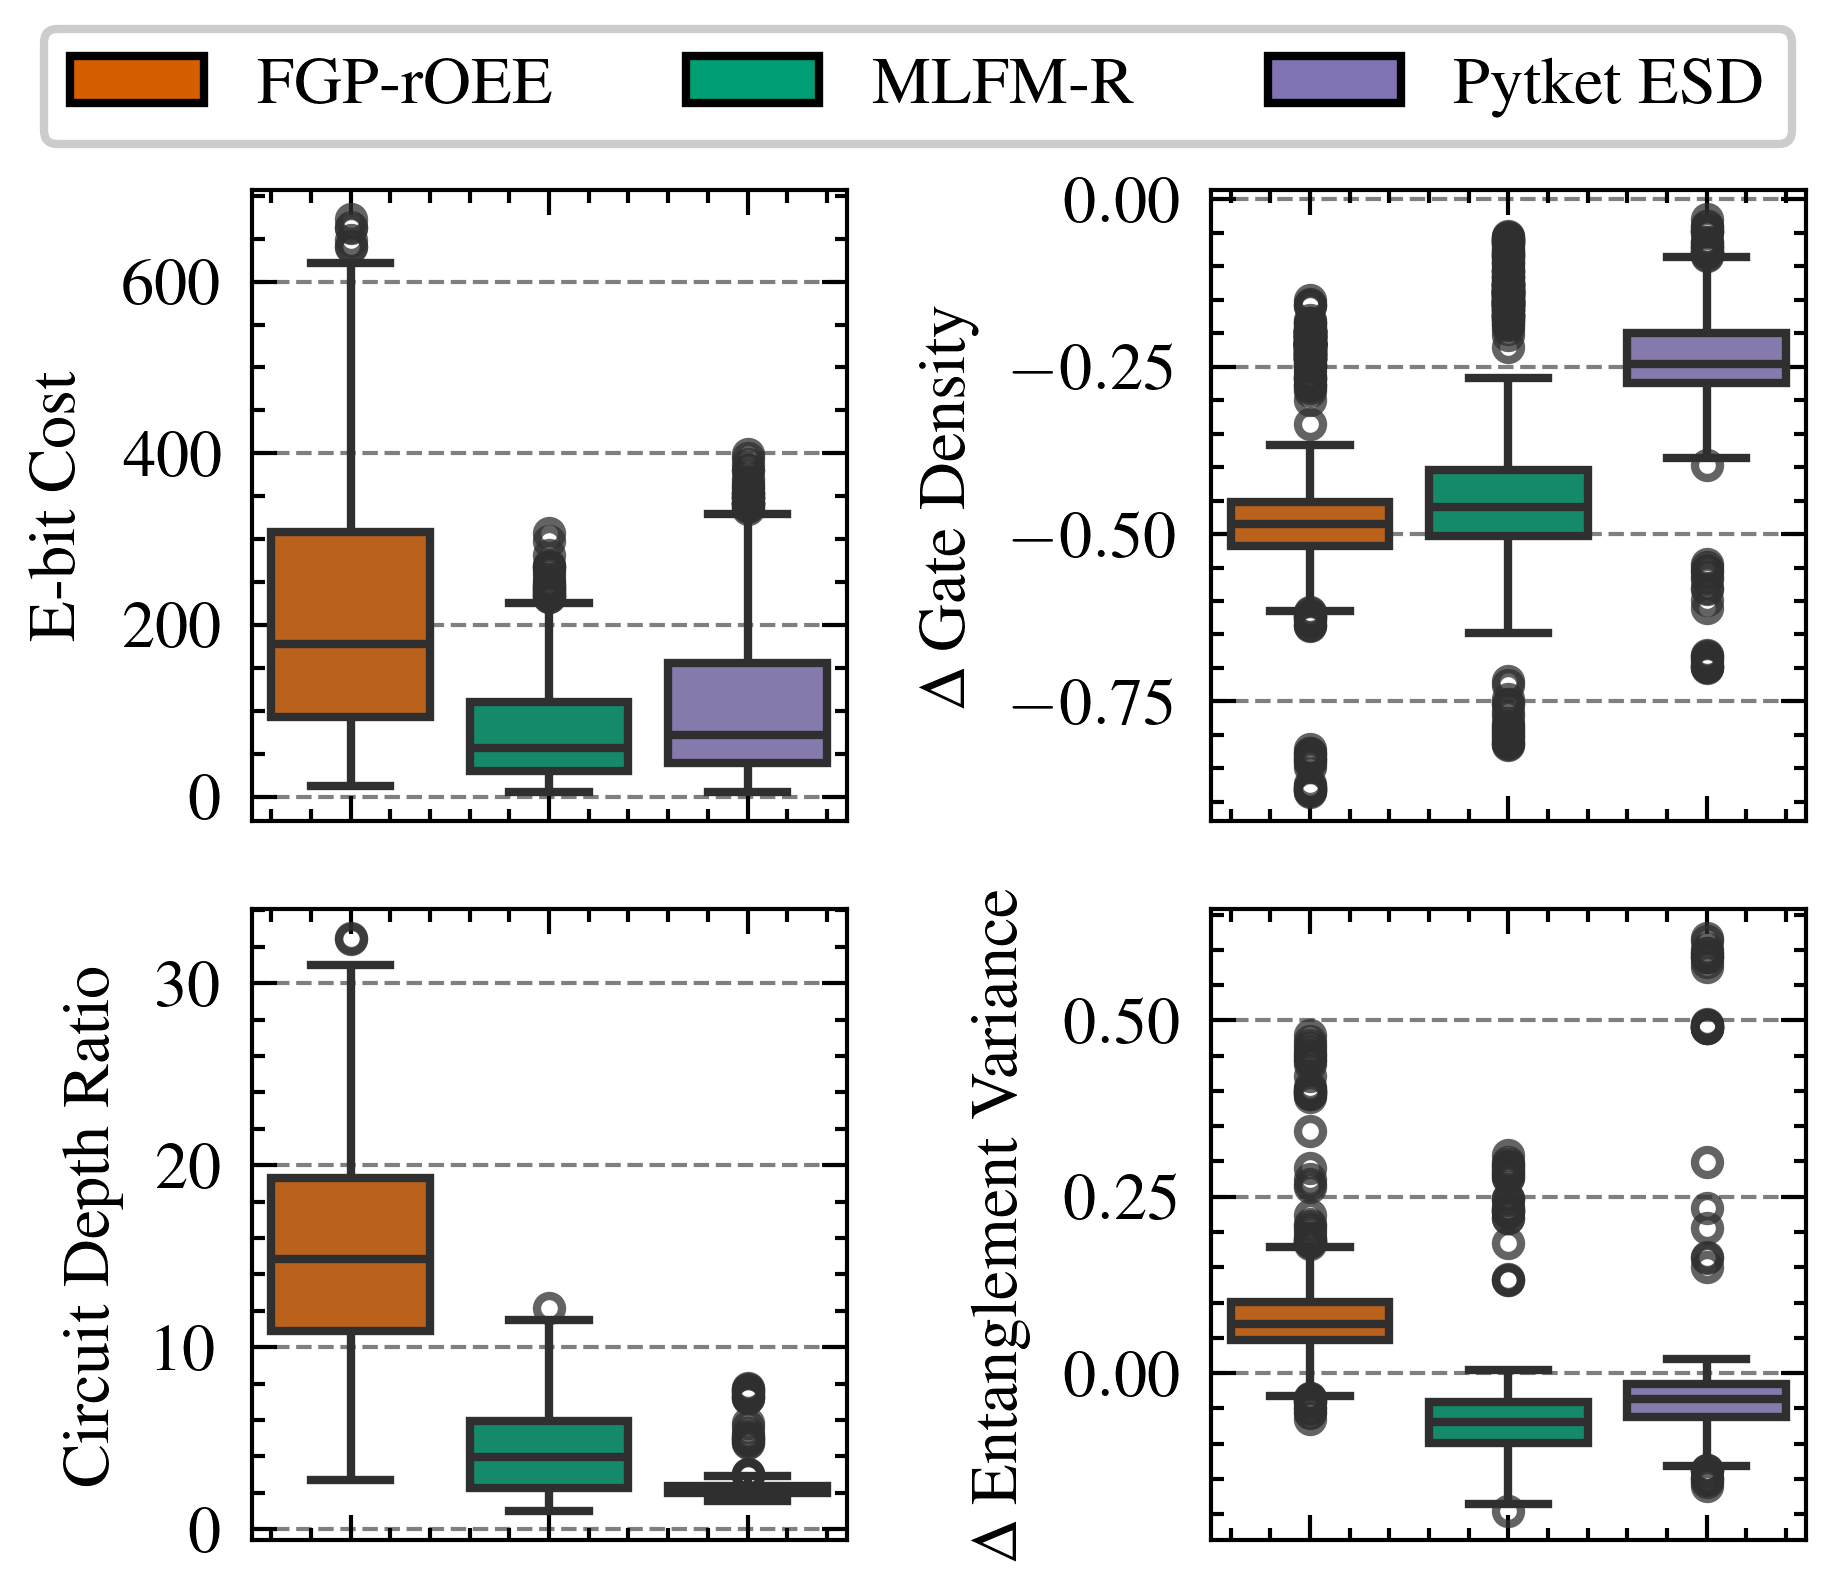

In [12]:
# Plotting
METRICS_TO_PLOT = [
    ("partition_ebit_cost", "E-bit Cost"),
    ("gate_density_delta", r"$\Delta$ Gate Density"),
    ("circuit_depth_ratio", "Circuit Depth Ratio"),
    ("entanglement_variance_delta", r"$\Delta$ Entanglement Variance"),
]

fig, axes = plt.subplots(
    2, 2, figsize=(FIGURE_WIDTH, FIGURE_HEIGHT), sharey=False
)
axes = axes.flatten()

for ax, (col, label) in zip(axes, METRICS_TO_PLOT):
    sns.boxplot(
        data=complete_experiments_df.dropna(subset=[col]),
        x="partitioner",
        y=col,
        order=PARTITIONER_LABELS,
        hue="partitioner",
        palette=PARTITIONER_PALETTE,
        ax=ax,
        flierprops=dict(marker="o", markersize=3, alpha=0.75)
    )
    ax.set_ylabel(label)
    ax.set_xlabel("")
    ax.set_xticklabels([])

handles = [
    matplotlib.patches.Patch(
        facecolor=PARTITIONER_PALETTE[partitioner],
        edgecolor="black",
        label=partitioner,
    )
    for partitioner in PARTITIONER_LABELS
]

fig.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.07),
    ncol=len(PARTITIONER_LABELS),
    frameon=True,
    # title="Partitioning Method",
)

plt.tight_layout()
plt.savefig(
    "figures/cost_metrics.pdf", bbox_inches="tight", dpi=300
)
plt.show()
